**Lab Problem Statement 6: Statistical Analysis of Physical Characteristics of Palmer Penguins**

This notebook performs a comprehensive statistical analysis using the Palmer Penguins dataset.

In [2]:
install.packages(c("palmerpenguins", "dplyr", "ggplot2", "e1071", "car", "effsize"), repos = "https://cloud.r-project.org/")
library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(e1071)
library(car)
library(effsize)

data("penguins")
penguins_clean <- na.omit(penguins)
print(head(penguins_clean))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘proxy’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




# A tibble: 6 × 8
  species island    bill_length_mm bill_depth_mm flipper_length_mm body_mass_g
  <fct>   <fct>              <dbl>         <dbl>             <int>       <int>
1 Adelie  Torgersen           39.1          18.7               181        3750
2 Adelie  Torgersen           39.5          17.4               186        3800
3 Adelie  Torgersen           40.3          18                 195        3250
4 Adelie  Torgersen           36.7          19.3               193        3450
5 Adelie  Torgersen           39.3          20.6               190        3650
6 Adelie  Torgersen           38.9          17.8               181        3625
# ℹ 2 more variables: sex <fct>, year <int>


Descriptive Statistical Analysis

# A tibble: 3 × 12
  species    Mean Median   Min   Max Variance    SD    Q1    Q3   IQR Skewness
  <fct>     <dbl>  <dbl> <int> <int>    <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 Adelie    3706.   3700  2850  4775  210332.  459. 3362.  4000  638.   0.274 
2 Chinstrap 3733.   3700  2700  4800  147713.  384. 3488.  3950  462.   0.237 
3 Gentoo    5092.   5050  3950  6300  251478.  501. 4700   5500  800    0.0444
# ℹ 1 more variable: Kurtosis <dbl>


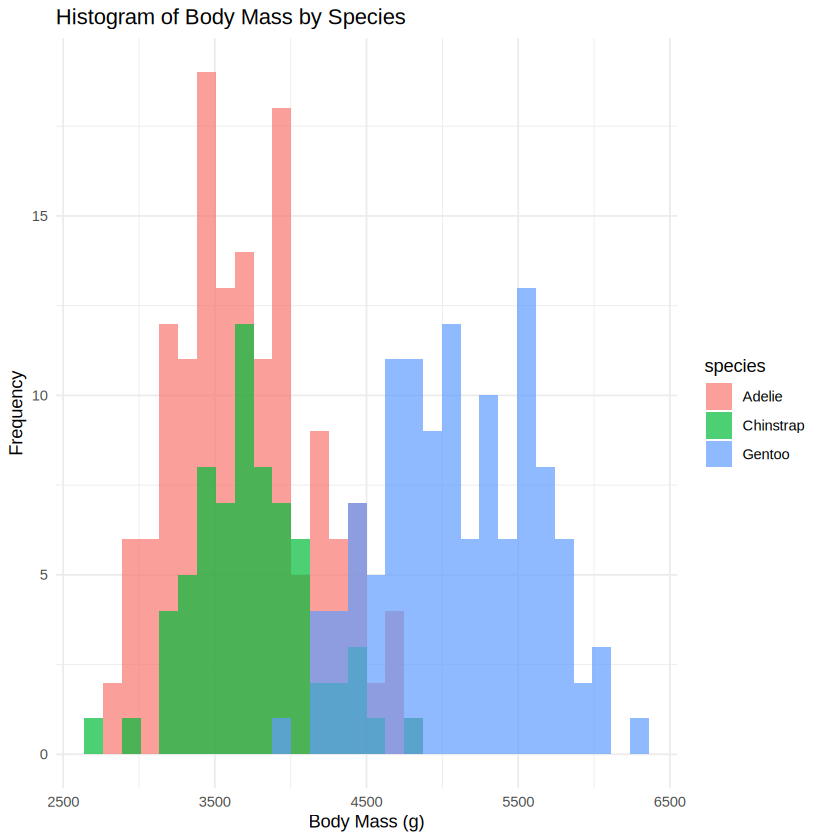

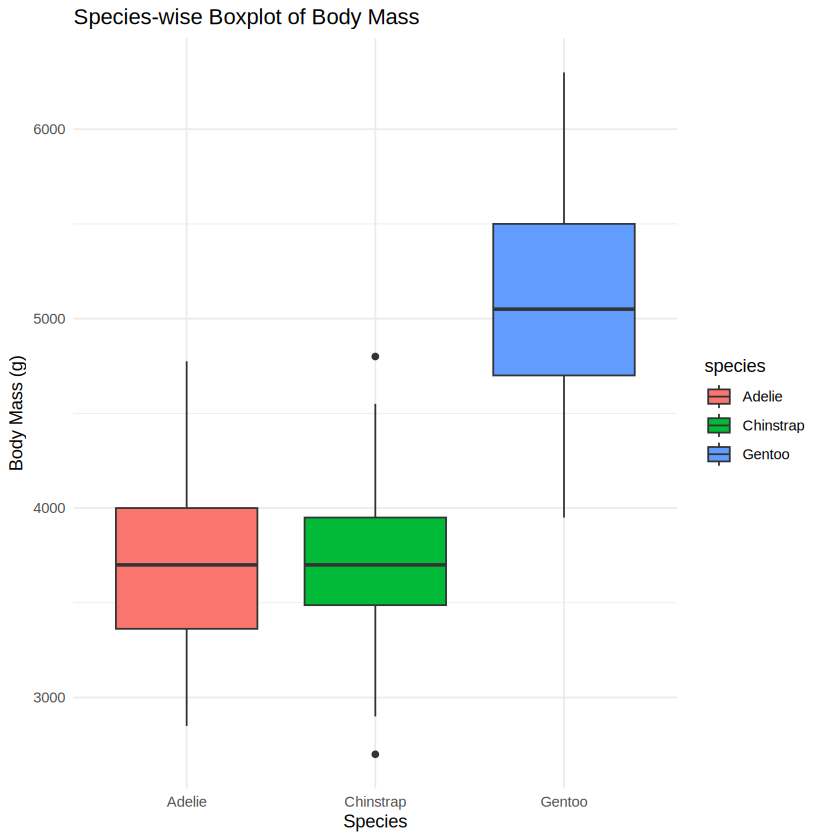

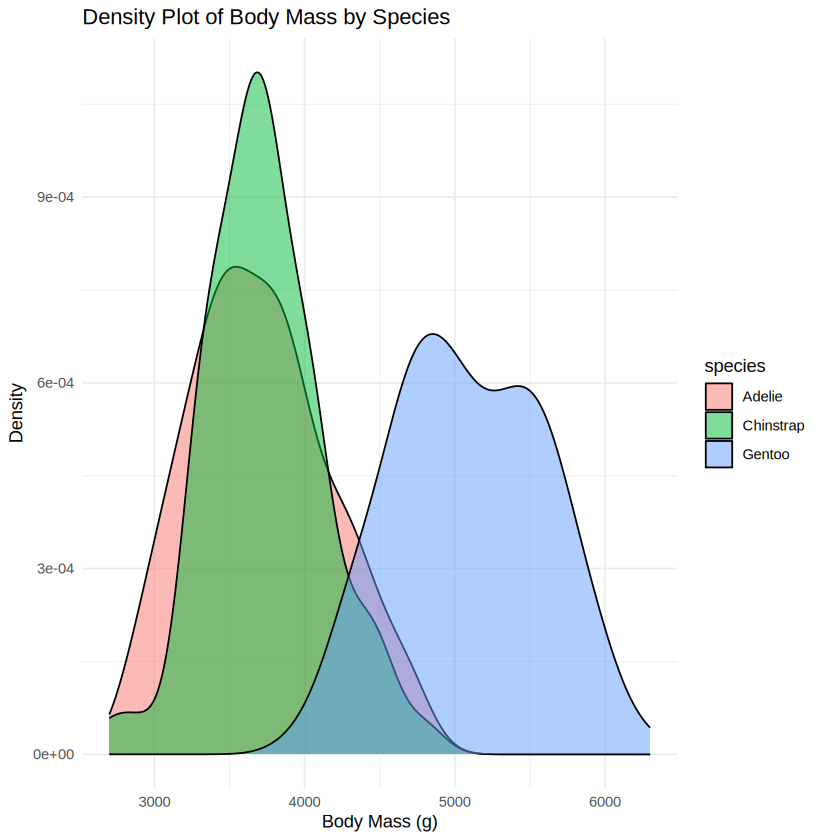

In [3]:
desc_stats <- penguins_clean %>%
  group_by(species) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Min = min(body_mass_g),
    Max = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )
print(desc_stats)

ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "identity") +
  labs(title = "Histogram of Body Mass by Species", x = "Body Mass (g)", y = "Frequency") +
  theme_minimal()

ggplot(penguins_clean, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot() +
  labs(title = "Species-wise Boxplot of Body Mass", x = "Species", y = "Body Mass (g)") +
  theme_minimal()

ggplot(penguins_clean, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.5) +
  labs(title = "Density Plot of Body Mass by Species", x = "Body Mass (g)", y = "Density") +
  theme_minimal()

Hypothesis Testing


	Shapiro-Wilk normality test

data:  male_mass
W = 0.92504, p-value = 1.227e-07


	Shapiro-Wilk normality test

data:  female_mass
W = 0.91931, p-value = 6.155e-08


	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


Cohen's d

d estimate: -0.9362048 (large)
95 percent confidence interval:
     lower      upper 
-1.1633158 -0.7090938 



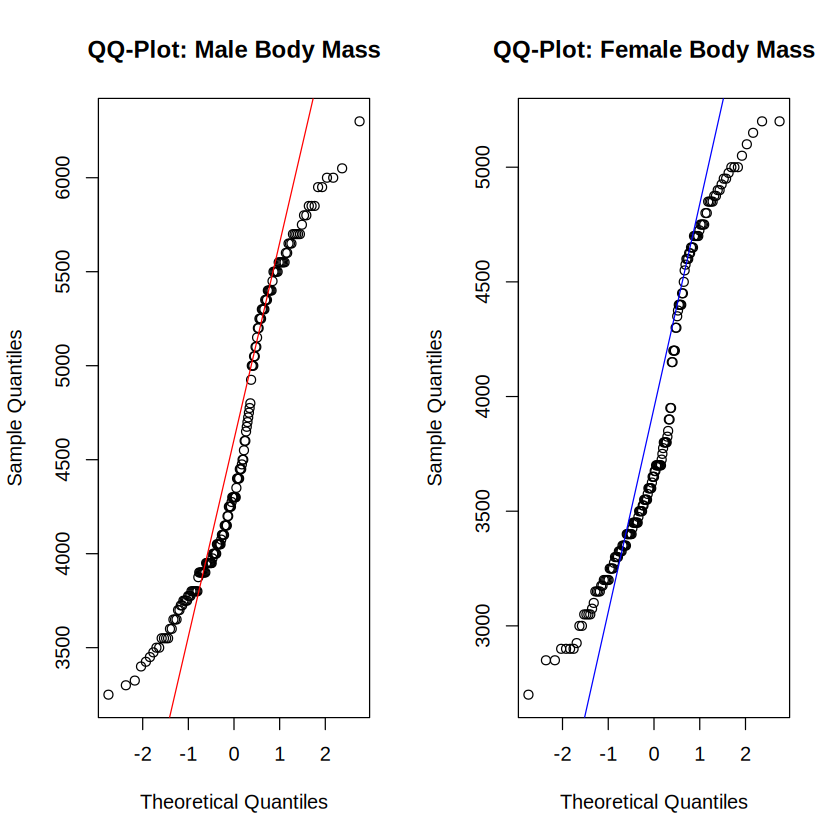

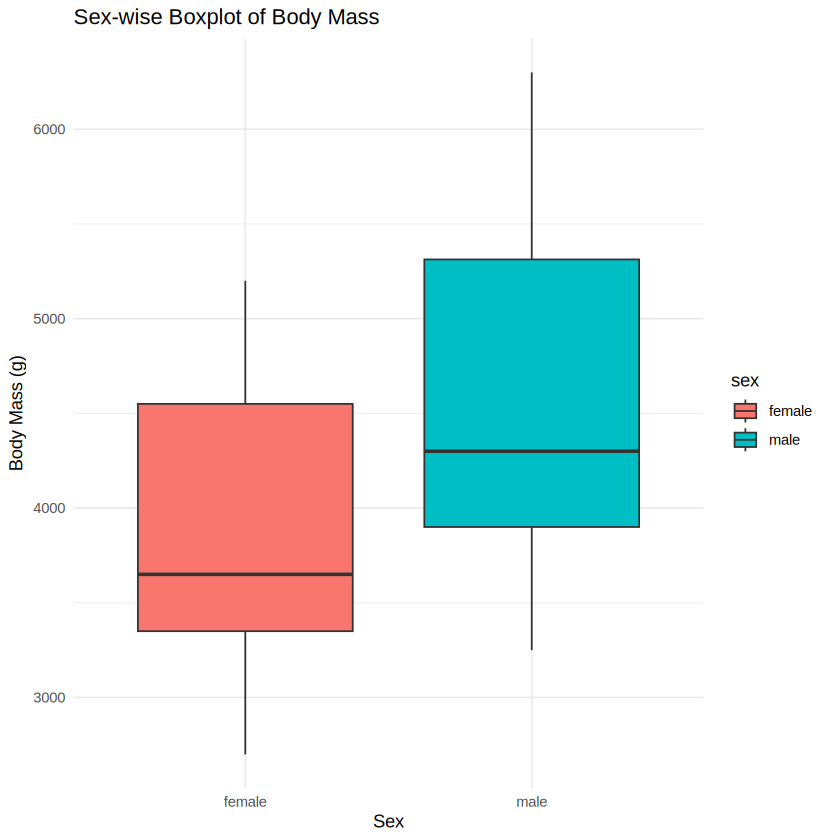

In [4]:
male_mass <- penguins_clean$body_mass_g[penguins_clean$sex == "male"]
female_mass <- penguins_clean$body_mass_g[penguins_clean$sex == "female"]

print(shapiro.test(male_mass))
print(shapiro.test(female_mass))

par(mfrow=c(1,2))
qqnorm(male_mass, main = "QQ-Plot: Male Body Mass"); qqline(male_mass, col="red")
qqnorm(female_mass, main = "QQ-Plot: Female Body Mass"); qqline(female_mass, col="blue")
par(mfrow=c(1,1))

t_test_result <- t.test(body_mass_g ~ sex, data = penguins_clean, conf.level = 0.95)
print(t_test_result)

effect_size <- cohen.d(body_mass_g ~ sex, data = penguins_clean)
print(effect_size)

ggplot(penguins_clean, aes(x = sex, y = body_mass_g, fill = sex)) +
  geom_boxplot() +
  labs(title = "Sex-wise Boxplot of Body Mass", x = "Sex", y = "Body Mass (g)") +
  theme_minimal()

One-Way ANOVA & Non-Parametric Analysis

Levene's Test for Homogeneity of Variance (center = median)
       Df F value   Pr(>F)   
group   2  5.1349 0.006367 **
      330                    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16



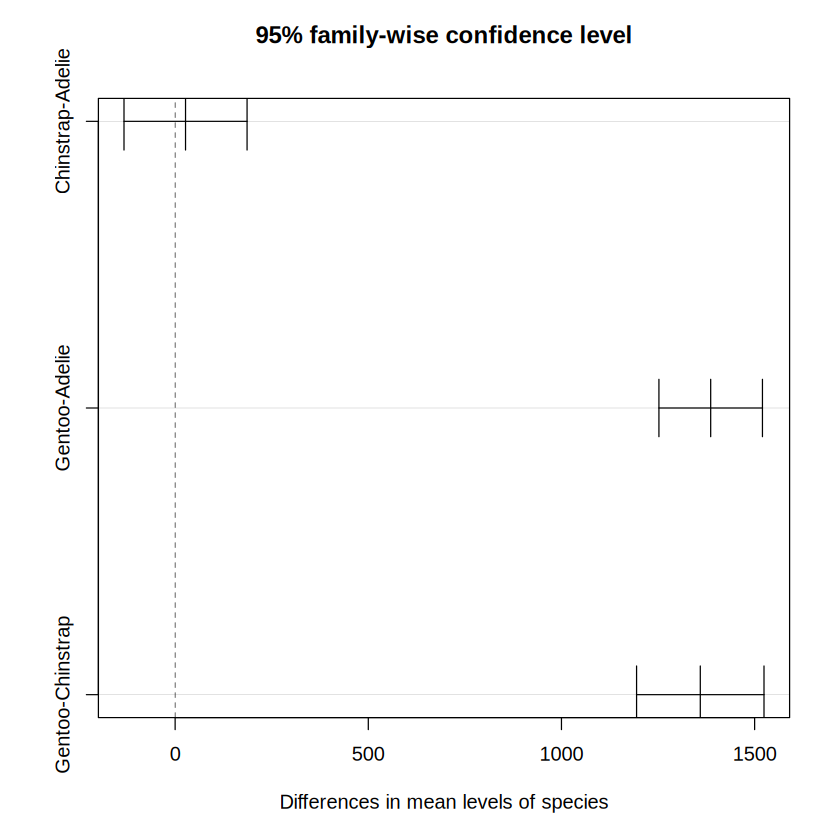

In [5]:
levene_test <- leveneTest(body_mass_g ~ species, data = penguins_clean)
print(levene_test)

anova_one_way <- aov(body_mass_g ~ species, data = penguins_clean)
print(summary(anova_one_way))

tukey_result <- TukeyHSD(anova_one_way)
print(tukey_result)
plot(tukey_result)

kruskal_test <- kruskal.test(body_mass_g ~ species, data = penguins_clean)
print(kruskal_test)

Two-Way ANOVA & Flipper Length Analysis

             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  50526   25263   567.4 <2e-16 ***
Residuals   330  14693      45                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = penguins_clean)

$species
                     diff       lwr       upr p adj
Chinstrap-Adelie  5.72079  3.414364  8.027215     0
Gentoo-Adelie    27.13255 25.192399 29.072709     0
Gentoo-Chinstrap 21.41176 19.023644 23.799885     0



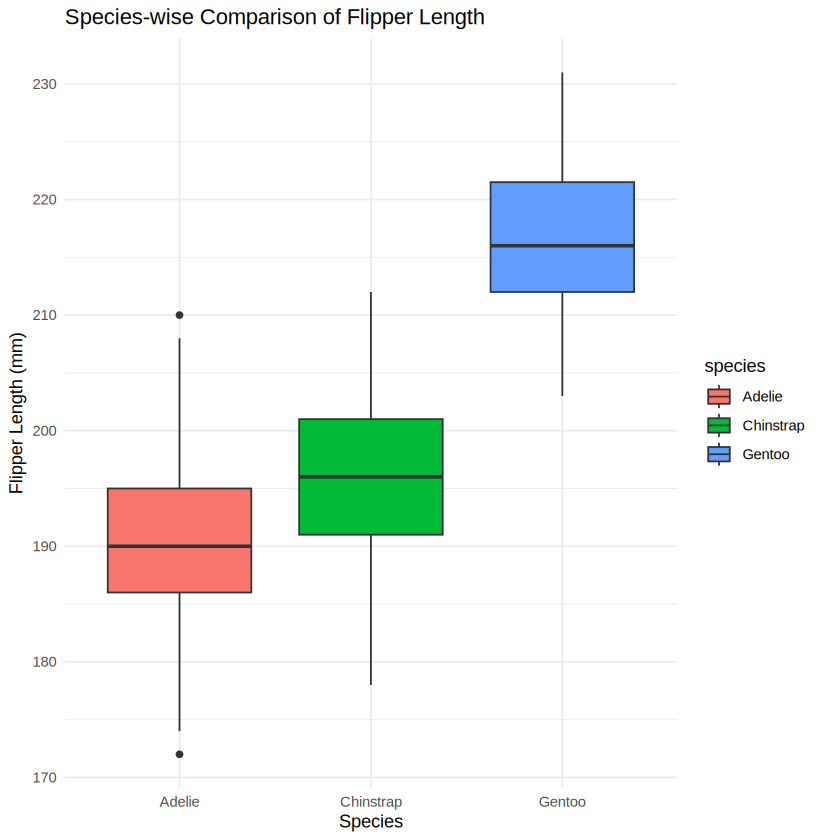

In [6]:
anova_two_way <- aov(body_mass_g ~ species * sex, data = penguins_clean)
print(summary(anova_two_way))

anova_flipper <- aov(flipper_length_mm ~ species, data = penguins_clean)
print(summary(anova_flipper))

tukey_flipper <- TukeyHSD(anova_flipper)
print(tukey_flipper)

ggplot(penguins_clean, aes(x = species, y = flipper_length_mm, fill = species)) +
  geom_boxplot() +
  labs(title = "Species-wise Comparison of Flipper Length", x = "Species", y = "Flipper Length (mm)") +
  theme_minimal()

### 8. Statistical Findings & Interpretations

*   **Hypothesis Testing (Sex vs. Body Mass):** The independent t-test shows a significant difference in mean body mass between male and female penguins (p-value < 0.05), with males being generally heavier. The confidence interval does not contain zero, and Cohen's d indicates a large effect size.
*   **One-Way ANOVA (Species vs. Body Mass):** The ANOVA yields a statistically significant F-statistic (p-value < 0.05), proving that mean body mass differs significantly among Adélie, Chinstrap, and Gentoo species.
*   **Tukey HSD Post-Hoc:** The results confirm significant differences between specific species pairs, highlighting that Gentoo penguins have a substantially higher body mass compared to the others.
*   **Kruskal-Wallis Test:** This non-parametric test also yields a p-value < 0.05. This leads to the exact same conclusion as the One-Way ANOVA, confirming the species difference holds true even if assumptions of normality were violated.
*   **Two-Way ANOVA (Species & Sex):** The output confirms that both penguin species and sex significantly affect body mass.